# Hierarchical emergency classification with pretrained AWD-LSTM

Fine-tune two fastai pretrained AWD-LSTM classifiers as a cascade: the first predicts the broad category, then the second predicts a subcategory conditioned on that category. At inference, the second stage is restricted to valid children of the predicted category.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from fastai.text.all import (
    AWD_LSTM,
    F1Score,
    TextDataLoaders,
    accuracy,
    text_classifier_learner,
)

from classification_utils import (
    category_to_id,
    subcategory_to_id,
    display_classification_analytics,
    load_labeled_csv,
    score_lstm_awd_lstm_class_probabilities,
    seed_everything,
    stratified_split,
)

In [2]:
SEED = 42
MODEL_NAME = "AWD-LSTM"

seed_everything(SEED)

In [3]:
category_names = [
    name for name, _ in sorted(category_to_id.items(), key=lambda item: item[1])
]

data = load_labeled_csv(
    Path("disaster_messages.csv"),
    text_column="message",
    label_column="category",
    label_to_id=category_to_id,
    encoded_label_column="category_labels",
)
unknown_subcategories = sorted(set(data["subcategory"]) - set(subcategory_to_id))
if unknown_subcategories:
    raise ValueError(f"Unknown subcategories: {unknown_subcategories}")

data["subcategory_path"] = data["category"] + "/" + data["subcategory"]
subcategory_names = sorted(data["subcategory_path"].unique())
subcategory_path_to_id = {
    name: label_id for label_id, name in enumerate(subcategory_names)
}
data["subcategory_labels"] = (
    data["subcategory_path"].map(subcategory_path_to_id).astype(int)
)

subcategory_paths_by_category = {
    category: [
        f"{category}/{subcategory}"
        for subcategory in sorted(
            group["subcategory"].unique(), key=subcategory_to_id.get
        )
    ]
    for category, group in data.groupby("category")
}
train_df, validation_df, test_df = stratified_split(
    data[[
        "message", "category", "subcategory", "subcategory_path",
        "category_labels", "subcategory_labels",
    ]],
    label_column="subcategory_labels",
    seed=SEED,
)
print(f"train={len(train_df):,}, validation={len(validation_df):,}, test={len(test_df):,}")
data.groupby(["category", "subcategory"]).size()

train=7,000, validation=1,500, test=1,500


category               subcategory    
evacuation             mandatory          516
                       voluntary          458
fire                   structural_fire    345
                       vehicle_fire       335
                       wildfire           369
flooding               flash_flood        328
                       house_flooding     378
                       street_flooding    345
infrastructure_damage  bridge             224
                       other              261
                       road               242
                       utility            239
medical                heavy_bleeding     203
                       illness            199
                       injury             183
                       light_bleeding     200
                       unconscious        201
missing_person         adult              331
                       child              305
                       elderly            346
structure_damage       light             

## Prepare both stages

Stage 1 maps the raw message to a category. Stage 2 receives both the category and message, and maps them to a globally unique `category/subcategory` label. During training, stage 2 uses the true category; during evaluation and prediction, it uses stage 1's prediction.

In [4]:
def make_subcategory_frame(frame, categories=None):
    result = frame.copy()
    if categories is not None:
        result["category"] = list(categories)
    result["message"] = (
        "category: " + result["category"] + " message: " + result["message"]
    )
    return result

def combine_training_frames(training_frame, validation_frame):
    training_with_flag = training_frame.copy()
    training_with_flag["is_valid"] = False
    validation_with_flag = validation_frame.copy()
    validation_with_flag["is_valid"] = True
    return pd.concat(
        [training_with_flag, validation_with_flag], ignore_index=True
    )

category_training_frame = combine_training_frames(train_df, validation_df)
subcategory_training_frame = combine_training_frames(
    make_subcategory_frame(train_df),
    make_subcategory_frame(validation_df),
)

category_data_loaders = TextDataLoaders.from_df(
    category_training_frame,
    path=Path("."),
    text_col="message",
    label_col="category",
    valid_col="is_valid",
    seq_len=72,
    bs=64,
)
subcategory_data_loaders = TextDataLoaders.from_df(
    subcategory_training_frame,
    path=Path("."),
    text_col="message",
    label_col="subcategory_path",
    valid_col="is_valid",
    seq_len=72,
    bs=64,
)

category_learner = text_classifier_learner(
    category_data_loaders,
    AWD_LSTM,
    pretrained=True,
    drop_mult=0.5,
    metrics=[accuracy, F1Score(average="macro")],
)
subcategory_learner = text_classifier_learner(
    subcategory_data_loaders,
    AWD_LSTM,
    pretrained=True,
    drop_mult=0.5,
    metrics=[accuracy, F1Score(average="macro")],
)
category_learner.model, subcategory_learner.model

(SequentialRNN(
   (0): SentenceEncoder(
     (module): AWD_LSTM(
       (encoder): Embedding(760, 400, padding_idx=1)
       (encoder_dp): EmbeddingDropout(
         (emb): Embedding(760, 400, padding_idx=1)
       )
       (rnns): ModuleList(
         (0): WeightDropout(
           (module): LSTM(400, 1152, batch_first=True)
         )
         (1): WeightDropout(
           (module): LSTM(1152, 1152, batch_first=True)
         )
         (2): WeightDropout(
           (module): LSTM(1152, 400, batch_first=True)
         )
       )
       (input_dp): RNNDropout()
       (hidden_dps): ModuleList(
         (0-2): 3 x RNNDropout()
       )
     )
   )
   (1): PoolingLinearClassifier(
     (layers): Sequential(
       (0): LinBnDrop(
         (0): BatchNorm1d(1200, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
         (1): Dropout(p=0.2, inplace=False)
         (2): Linear(in_features=1200, out_features=50, bias=False)
         (3): ReLU(inplace=True)
      

## Fine-tune category first, then subcategory

For each stage, train the new classification head for one frozen epoch, then gradually unfreeze and fine-tune the pretrained recurrent encoder.

In [5]:
category_learner.fine_tune(3, base_lr=1e-2, freeze_epochs=1)
subcategory_learner.fine_tune(3, base_lr=1e-2, freeze_epochs=1)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,1.293391,0.636848,0.798000,0.794637,00:07


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.448439,0.137530,0.960667,0.960754,00:12
1,0.177016,0.050568,0.984667,0.984689,00:12
2,0.086847,0.042349,0.986667,0.986851,00:08


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,1.885139,1.001375,0.632000,0.586735,00:04


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.631598,0.196659,0.938667,0.932180,00:12
1,0.234878,0.051303,0.986667,0.983712,00:13
2,0.126207,0.039867,0.985333,0.981527,00:13


## Evaluate the cascade

First evaluate broad-category classification. Then condition the second classifier on each predicted category and mask its output to valid children. The subcategory metrics therefore include error propagation from stage 1 and match production inference.

Accuracy: 0.9833
Macro Precision: 0.9839
Macro Recall: 0.9835
Macro F1: 0.9836

                       precision    recall  f1-score   support

              medical       0.99      0.99      0.99       148
     structure_damage       0.96      0.99      0.98       150
              utility       0.95      0.99      0.97       156
       missing_person       1.00      0.97      0.99       148
       supply_request       0.99      1.00      0.99       150
             flooding       1.00      0.95      0.97       157
              trapped       1.00      0.99      1.00       143
                 fire       0.97      0.98      0.98       157
infrastructure_damage       0.98      0.99      0.99       146
           evacuation       0.99      0.98      0.99       145

             accuracy                           0.98      1500
            macro avg       0.98      0.98      0.98      1500
         weighted avg       0.98      0.98      0.98      1500

ROC AUC: 0.9999


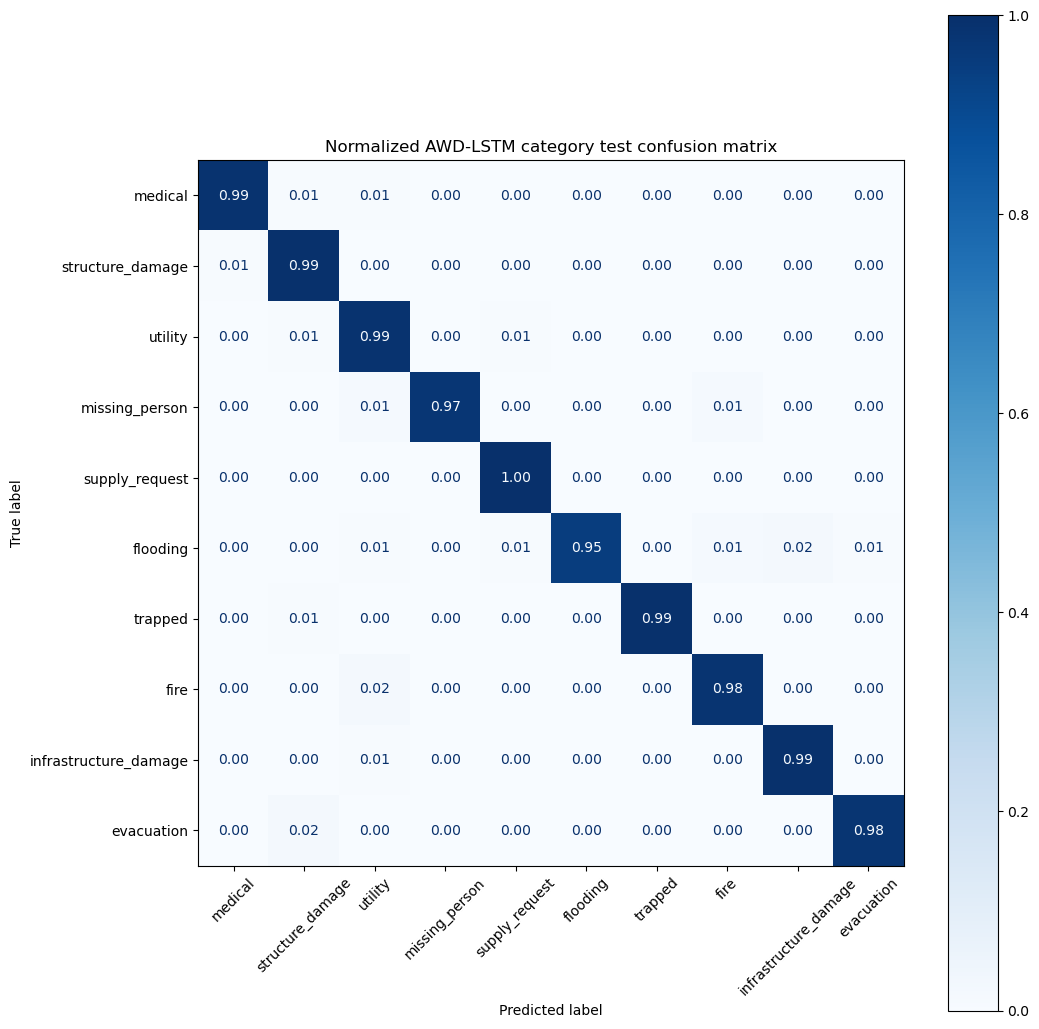

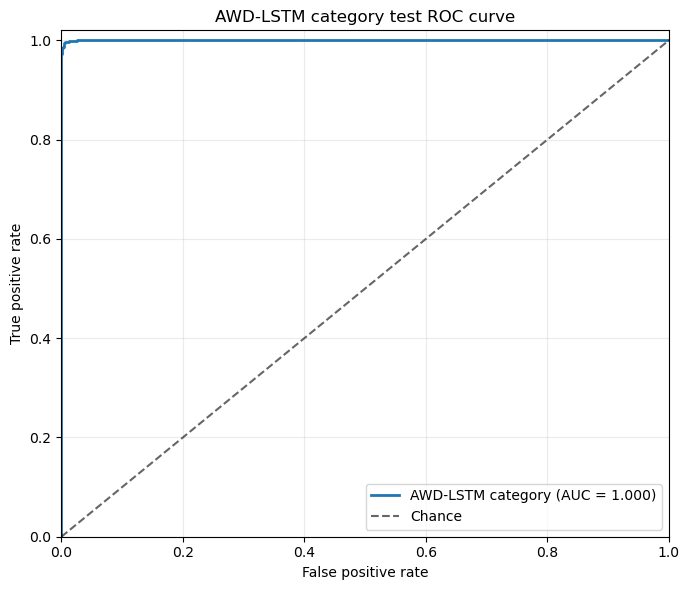

In [6]:
category_probabilities = score_lstm_awd_lstm_class_probabilities(
    category_learner,
    test_df["message"].tolist(),
    category_names,
)
predicted_category_ids = category_probabilities.argmax(axis=1)
predicted_categories = [
    category_names[label_id] for label_id in predicted_category_ids
]

category_analytics = display_classification_analytics(
    test_df["category_labels"].to_numpy(),
    category_names,
    probabilities=category_probabilities,
    model_name=MODEL_NAME + " category",
)

Accuracy: 0.9780
Macro Precision: 0.9794
Macro Recall: 0.9785
Macro F1: 0.9784

                               precision    recall  f1-score   support

         evacuation/mandatory       0.97      1.00      0.99        77
         evacuation/voluntary       1.00      0.94      0.97        68
         fire/structural_fire       0.91      0.98      0.94        51
            fire/vehicle_fire       1.00      0.94      0.97        51
                fire/wildfire       1.00      1.00      1.00        55
         flooding/flash_flood       1.00      0.96      0.98        49
      flooding/house_flooding       1.00      0.95      0.97        57
     flooding/street_flooding       1.00      0.94      0.97        51
 infrastructure_damage/bridge       0.94      0.97      0.96        34
  infrastructure_damage/other       0.97      1.00      0.99        39
   infrastructure_damage/road       0.97      1.00      0.99        37
infrastructure_damage/utility       1.00      0.97      0.99       

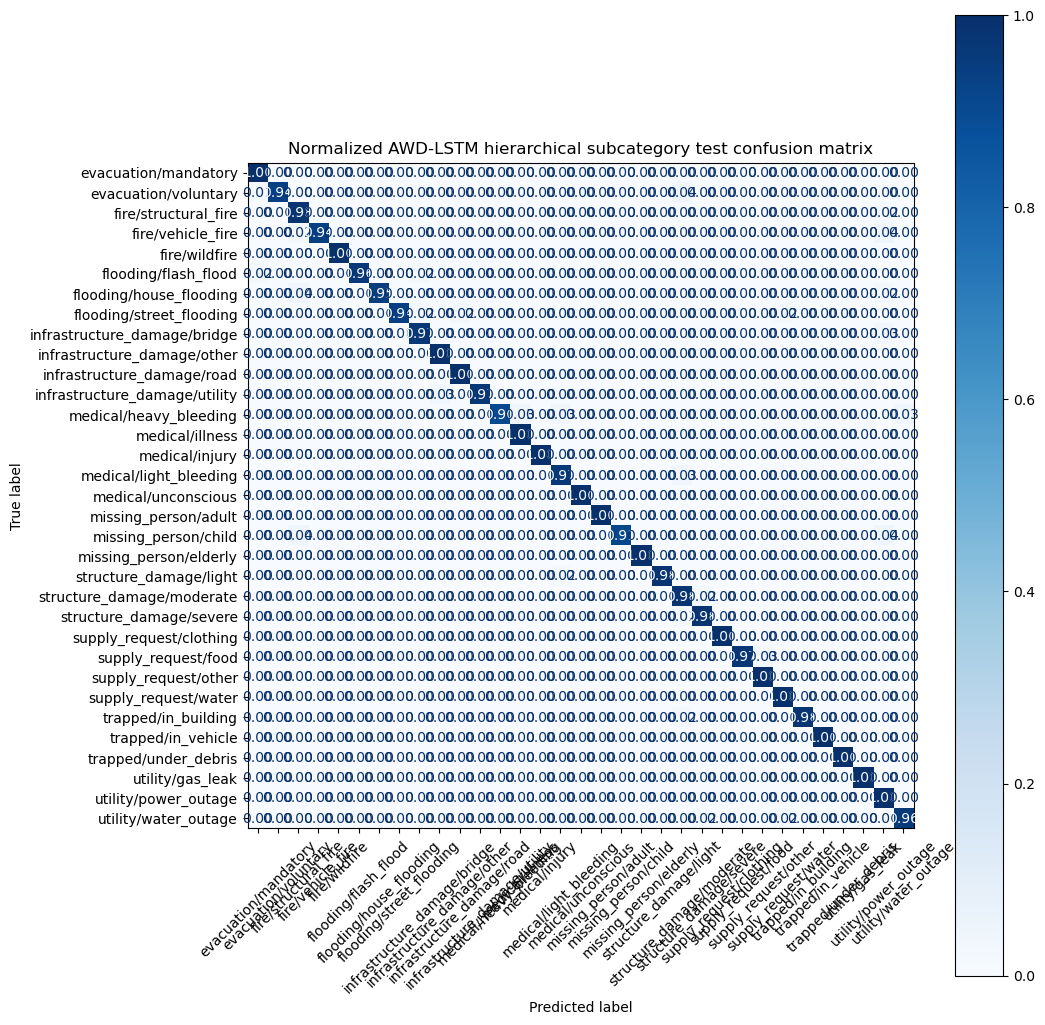

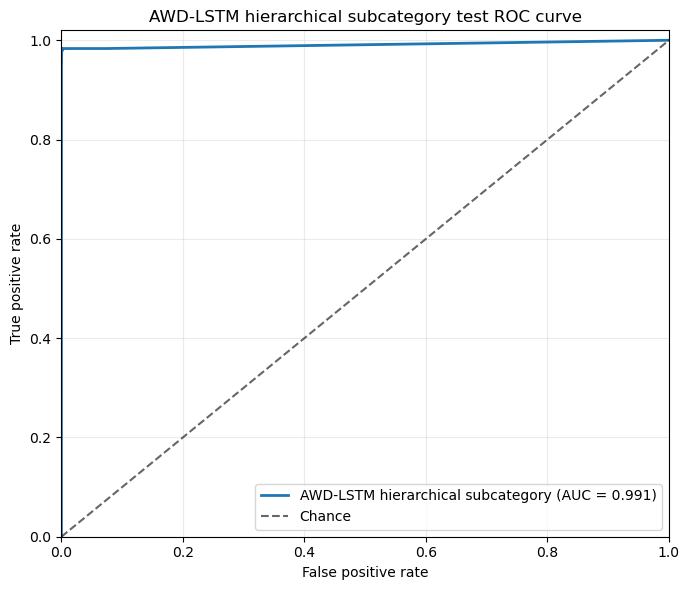

In [7]:
stage_two_frame = make_subcategory_frame(test_df, predicted_categories)
raw_subcategory_probabilities = score_lstm_awd_lstm_class_probabilities(
    subcategory_learner,
    stage_two_frame["message"].tolist(),
    subcategory_names,
)
subcategory_probabilities = np.zeros_like(raw_subcategory_probabilities)

for row_id, category in enumerate(predicted_categories):
    allowed_columns = [
        subcategory_path_to_id[path]
        for path in subcategory_paths_by_category[category]
    ]
    allowed_scores = raw_subcategory_probabilities[row_id, allowed_columns]
    subcategory_probabilities[row_id, allowed_columns] = (
        allowed_scores / allowed_scores.sum()
    )

subcategory_analytics = display_classification_analytics(
    test_df["subcategory_labels"].to_numpy(),
    subcategory_names,
    probabilities=subcategory_probabilities,
    model_name=MODEL_NAME + " hierarchical subcategory",
)

## Save and predict

In [8]:
category_model_path = Path("models/awd_lstm_category.pkl")
subcategory_model_path = Path("models/awd_lstm_subcategory.pkl")
category_model_path.parent.mkdir(parents=True, exist_ok=True)
category_learner.export(category_model_path)
subcategory_learner.export(subcategory_model_path)

def predict_emergency(text):
    category_scores = score_lstm_awd_lstm_class_probabilities(
        category_learner, [text], category_names
    )[0]
    category_id = int(category_scores.argmax())
    category = category_names[category_id]

    stage_two_text = f"category: {category} message: {text}"
    raw_subcategory_scores = score_lstm_awd_lstm_class_probabilities(
        subcategory_learner, [stage_two_text], subcategory_names
    )[0]
    allowed_paths = subcategory_paths_by_category[category]
    allowed_columns = [subcategory_path_to_id[path] for path in allowed_paths]
    allowed_scores = raw_subcategory_scores[allowed_columns]
    allowed_scores = allowed_scores / allowed_scores.sum()
    local_subcategory_id = int(allowed_scores.argmax())
    subcategory_path = allowed_paths[local_subcategory_id]

    return {
        "category": category,
        "category_confidence": float(category_scores[category_id]),
        "subcategory": subcategory_path.split("/", 1)[1],
        "subcategory_confidence_given_category": float(
            allowed_scores[local_subcategory_id]
        ),
    }

for message in ["fire in building", "send an ambulance", "we are trapped"]:
    print(f"{message!r} -> {predict_emergency(message)}")

'fire in building' -> {'category': 'fire', 'category_confidence': 0.8824638724327087, 'subcategory': 'structural_fire', 'subcategory_confidence_given_category': 0.9996258616447449}


'send an ambulance' -> {'category': 'structure_damage', 'category_confidence': 0.5572622418403625, 'subcategory': 'severe', 'subcategory_confidence_given_category': 0.5479464530944824}


'we are trapped' -> {'category': 'trapped', 'category_confidence': 0.5929101705551147, 'subcategory': 'in_building', 'subcategory_confidence_given_category': 0.956542432308197}
